In [1]:
# Project 8: Customer Segmentation
# Framework: Discovering Hidden Behavior Clusters via Unsupervised Learning

In [2]:
# Feature Engineering: Extract key operational customer behavior indicators (like visit frequency and direct transactional spending).

# Data Normalization: Standardize data scales so that large metric numbers (like ₹15,000 spend) do not mathematically drown out smaller metrics (like 5 support tickets).

# Unsupervised Clustering Engine: Deploy the K-Means Clustering algorithm to automatically group customers based on multi-dimensional mathematical proximity.

# Profile Generation: Aggregation of cluster means to define concrete customer buyer personas.

In [5]:
#Synthetic Customer Database Generation
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set seed for reproducible cluster extraction
np.random.seed(42)
n_customers = 600

# Generating raw customer interaction metrics
data_segmentation = {
    'CustomerID': [f'USR-{i:03d}' for i in range(1, n_customers + 1)],
    'Total_Spend_INR': np.concatenate([
        np.random.normal(loc=12000, scale=2000, size=200),  # Group A
        np.random.normal(loc=3500, scale=800, size=200),    # Group B
        np.random.normal(loc=1500, scale=400, size=200)     # Group C
    ]),
    'Purchase_Frequency_Monthly': np.concatenate([
        np.random.normal(loc=12, scale=2, size=200),
        np.random.normal(loc=3, scale=1, size=200),
        np.random.normal(loc=8, scale=1.5, size=200)
    ])
}

df_cust = pd.DataFrame(data_segmentation)
# Enforce absolute boundaries on financial metrics
df_cust['Total_Spend_INR'] = df_cust['Total_Spend_INR'].clip(lower=200).round(2)
df_cust['Purchase_Frequency_Monthly'] = df_cust['Purchase_Frequency_Monthly'].clip(lower=1).round(0)

print("Raw Unlabeled Customer Asset Loaded")
df_cust.head()

Raw Unlabeled Customer Asset Loaded


,CustomerID,Total_Spend_INR,Purchase_Frequency_Monthly
0,USR-001,12993.43,14.0
1,USR-002,11723.47,10.0
2,USR-003,13295.38,14.0
3,USR-004,15046.06,15.0
4,USR-005,11531.69,13.0


In [7]:
# Feature Scaling & K-Means Engine Execution
features = ['Total_Spend_INR', 'Purchase_Frequency_Monthly']
X_raw = df_cust[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cust['Cluster_ID'] = kmeans_model.fit_predict(X_scaled)

print("--- Unsupervised Clustering Completed Successfully ---")
df_cust[['CustomerID', 'Total_Spend_INR', 'Purchase_Frequency_Monthly', 'Cluster_ID']].head()

--- Unsupervised Clustering Completed Successfully ---


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,CustomerID,Total_Spend_INR,Purchase_Frequency_Monthly,Cluster_ID
0,USR-001,12993.43,14.0,1
1,USR-002,11723.47,10.0,1
2,USR-003,13295.38,14.0,1
3,USR-004,15046.06,15.0,1
4,USR-005,11531.69,13.0,1


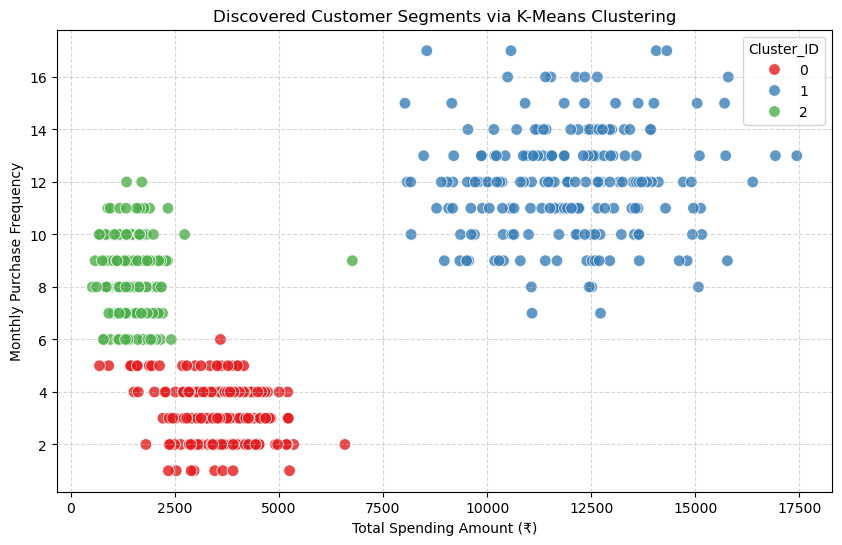

In [9]:
#Visualizing Customer Segments
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Create a scatter plot colored by the discovered Cluster IDs
sns.scatterplot(
    data=df_cust, 
    x='Total_Spend_INR', 
    y='Purchase_Frequency_Monthly', 
    hue='Cluster_ID', 
    palette='Set1', 
    s=70, 
    alpha=0.8
)
plt.title('Discovered Customer Segments via K-Means Clustering')
plt.xlabel('Total Spending Amount (₹)')
plt.ylabel('Monthly Purchase Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [11]:
#Generating Cluster Profiles
cluster_profiles = df_cust.groupby('Cluster_ID').agg(
    Average_Spend_INR=('Total_Spend_INR', 'mean'),
    Average_Frequency=('Purchase_Frequency_Monthly', 'mean'),
    Customer_Count=('CustomerID', 'count')
).reset_index()

print("Discovered Customer Cluster Profiles Matrix")
cluster_profiles

Discovered Customer Cluster Profiles Matrix


,Cluster_ID,Average_Spend_INR,Average_Frequency,Customer_Count
0,0,3489.704038,3.168269,208
1,1,11944.377588,12.010050,199
2,2,1491.132642,8.357513,193
